### Lasso Regression 

#### import required libraries

In [27]:
import pandas as pd

In [28]:
data=pd.read_csv("50_Startups.csv")
data

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


### dataa Understanding

In [29]:
data.shape

(50, 5)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [31]:
data.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

In [32]:
data.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [33]:
data.duplicated().sum()

np.int64(0)

In [34]:
data["Profit"].describe()

count        50.000000
mean     112012.639200
std       40306.180338
min       14681.400000
25%       90138.902500
50%      107978.190000
75%      139765.977500
max      192261.830000
Name: Profit, dtype: float64

<Axes: xlabel='Profit', ylabel='Count'>

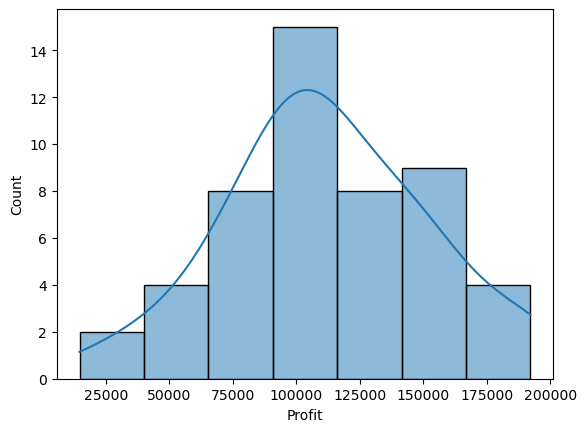

In [35]:
import seaborn as sns

sns.histplot(data["Profit"], kde=True)

<Axes: xlabel='Profit'>

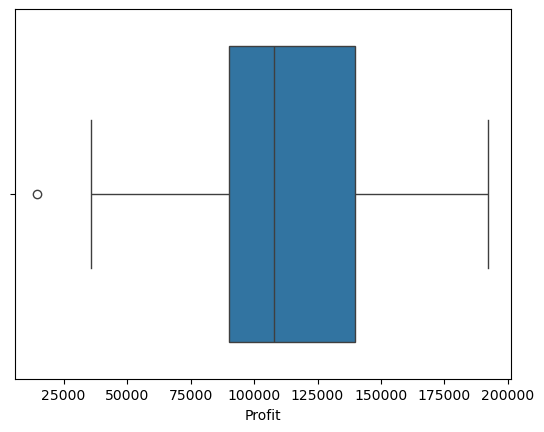

In [36]:
sns.boxplot(x=data["Profit"])

In [37]:
data["Profit"].skew()

np.float64(0.023291019769116614)

### EDA

#### Numerical Col

In [38]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
R&D Spend,50.0,73721.6156,45902.256482,0.00,39936.3700,73051.080,101602.8000,165349.20
Administration,50.0,121344.6396,28017.802755,51283.14,103730.8750,122699.795,144842.1800,182645.56
Marketing Spend,50.0,211025.0978,122290.310726,0.00,129300.1325,212716.240,299469.0850,471784.10
Profit,50.0,112012.6392,40306.180338,14681.40,90138.9025,107978.190,139765.9775,192261.83


In [39]:
data.describe(include='all').T ## if categorical col exist

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
R&D Spend,50.0,NaN,NaN,NaN,73721.6156,45902.256482,0.0,39936.37,73051.08,101602.8,165349.2
Administration,50.0,NaN,NaN,NaN,121344.6396,28017.802755,51283.14,103730.875,122699.795,144842.18,182645.56
Marketing Spend,50.0,NaN,NaN,NaN,211025.0978,122290.310726,0.0,129300.1325,212716.24,299469.085,471784.1
State,50,3,New York,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profit,50.0,NaN,NaN,NaN,112012.6392,40306.180338,14681.4,90138.9025,107978.19,139765.9775,192261.83


In [40]:
### histogram 

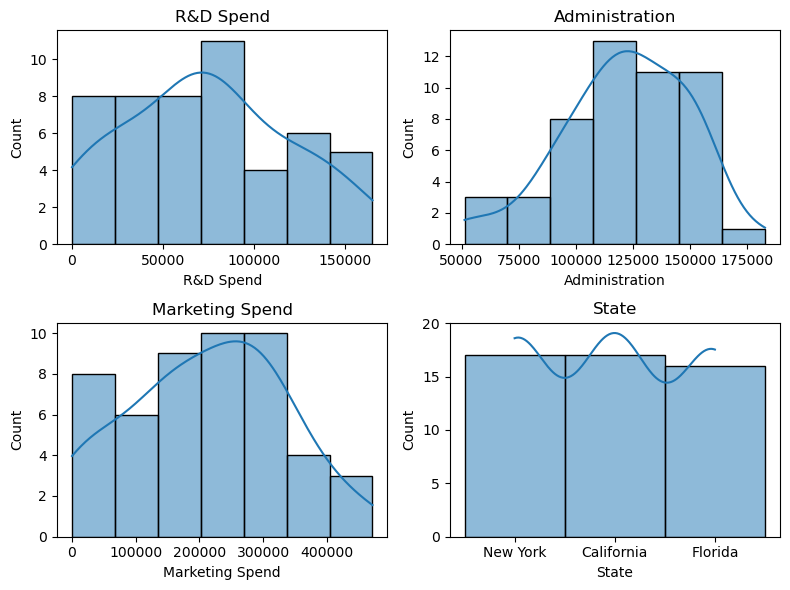

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
num = data.drop(columns='Profit').columns

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for ax, col in zip(axes, num):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

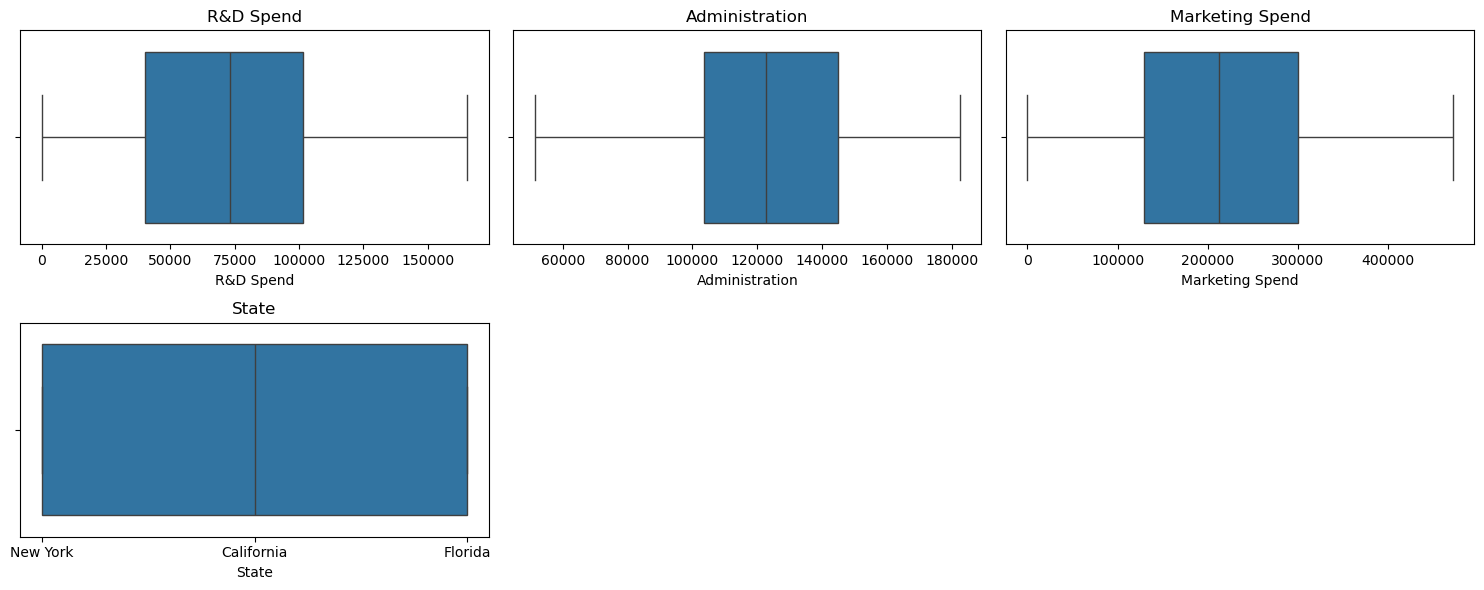

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = 3
rows = (len(num) + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
axes = axes.flatten()

for i, col in enumerate(num):
    sns.boxplot(x=data[col], ax=axes[i])
    axes[i].set_title(col)

# Extra empty plots remove
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### skewness with values

In [43]:
data.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [44]:
data[['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']].skew()

R&D Spend          0.164002
Administration    -0.489025
Marketing Spend   -0.046472
Profit             0.023291
dtype: float64

In [45]:
#### outlier

In [46]:
num=['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']

In [47]:
for col in num:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

R&D Spend: 0 outliers
Administration: 0 outliers
Marketing Spend: 0 outliers
Profit: 1 outliers


In [48]:
#### corelation

In [49]:
data.corr(numeric_only=True)["Profit"].sort_values(ascending=False)

Profit             1.000000
R&D Spend          0.972900
Marketing Spend    0.747766
Administration     0.200717
Name: Profit, dtype: float64

In [50]:
### data transformation

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['State'] = le.fit_transform(data['State'])

#### train test split

In [53]:
x=data.drop(labels=("Profit"),axis=1)

In [54]:
y=data["Profit"]

In [55]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_sc=sc.fit_transform(x)

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
x_train,x_test,y_train,y_test=train_test_split(x_sc,y,test_size=0.20,random_state=42)

### feture scaling

In [ ]:
#from sklearn.preprocessing import StandardScaler

In [ ]:
#sc=StandardScaler()

In [ ]:
#x_train_sc=sc.fit_transform(x_train)

In [ ]:
#x_test_sc=sc.transform(x_test)

In [ ]:
### Model building

In [58]:
from sklearn.linear_model import Lasso
# Model
model = Lasso(alpha=0.1)

# Train
model.fit(x_train, y_train)

Lasso(alpha=0.1)

#### Trainng Accuracy

In [59]:
from sklearn.metrics import r2_score

In [60]:
y_pred_train=model.predict(x_train)

In [61]:
print("R2 Score:", r2_score(y_train,y_pred_train))

R2 Score: 0.9535928780381352


In [62]:
### test Accuracy

In [63]:
y_pred_test=model.predict(x_test)

In [64]:
print("R2 Score:", r2_score(y_test,y_pred_test))

R2 Score: 0.9000637965491762


In [65]:
### underfitting 

In [66]:
print("Train R2 Score:", r2_score(y_train,y_pred_train))
print("Test R2 Score:", r2_score(y_test,y_pred_test))

Train R2 Score: 0.9535928780381352
Test R2 Score: 0.9000637965491762


In [67]:
print(model.coef_)

[ 3.65255025e+04 -1.88359023e+03  3.78402655e+03 -1.37508767e+01]


In [68]:
from sklearn.model_selection import cross_val_score

model=Lasso(alpha=0.1)

score=cross_val_score(model,x_sc,y,cv=5)

In [69]:
print(score)
print("Mean Accuracy:", score.mean())

[ 0.89080685 -0.99789883 -0.79153241 -0.76069498  0.38692043]
Mean Accuracy: -0.2544797870301526


In [70]:
print(x.shape)
print(y.shape)

(50, 4)
(50,)


In [73]:
from sklearn.linear_model import Ridge

lr =Ridge()

scores = cross_val_score(lr,x_sc, y, cv=5)

print(scores)
print(scores.mean())

[ 0.86011498 -1.04890446 -1.21706278 -0.40142325  0.29795004]
-0.3018650949897971


In [ ]:
print(x.shape)
print(y.shape)

In [74]:
print(lr.coef_)

AttributeError: 'Ridge' object has no attribute 'coef_'